In [3]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import ViTModel, AutoImageProcessor
from PIL import Image
import os
import re
from collections import Counter

In [4]:
FLICKR_IMG_DIR = "./flickr8k/Images"
FLICKR_ANN_FILE = "./flickr8k/captions.txt"

In [5]:
EMBED_DIM = 768
LSTM_HIDDEN = 512
NUM_LAYERS = 2
MAX_LEN = 30
BATCH_SIZE = 32
EPOCHS = 10
LR = 3e-4
VOCAB_MIN_FREQ = 3

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

Using: cuda


In [7]:
class Vocabulary:
    def __init__(self):
        self.word2idx = {"<PAD>": 0, "<SOS>": 1, "<EOS>": 2, "<UNK>": 3}
        self.idx2word = {0: "<PAD>", 1: "<SOS>", 2: "<EOS>", 3: "<UNK>"}
        self.freq = Counter()

    def build(self, captions, min_freq=VOCAB_MIN_FREQ):
        for caption in captions:
            for word in self.tokenize(caption):
                self.freq[word] += 1
        for word, count in self.freq.items():
            if count >= min_freq:
                idx = len(self.word2idx)
                self.word2idx[word] = idx
                self.idx2word[idx] = word
        print(f"Vocabulary size: {len(self.word2idx)}")

    def tokenize(self, text):
        return re.sub(r"[^a-z0-9 ]", "", text.lower()).split()

    def encode(self, caption):
        tokens = [self.word2idx.get(w, 3) for w in self.tokenize(caption)]
        return [1] + tokens[:MAX_LEN] + [2]

    def decode(self, indices):
        words = []
        for idx in indices:
            if idx == 2:
                break
            if idx not in [0, 1, 3]:
                words.append(self.idx2word.get(idx, "<UNK>"))
        return " ".join(words)

    def __len__(self):
        return len(self.word2idx)

In [8]:
class Flickr8kDataset(Dataset):
    def __init__(self, img_dir, ann_file, vocab, processor):
        self.img_dir = img_dir
        self.processor = processor
        self.vocab = vocab
        self.data = []

        with open(ann_file, "r") as f:
            lines = f.readlines()[1:]
        for line in lines:
            parts = line.strip().split(",", 1)
            if len(parts) == 2:
                self.data.append((parts[0].strip(), parts[1].strip()))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_name, caption = self.data[idx]
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert("RGB")
        inputs = self.processor(images=image, return_tensors="pt")
        pixel_values = inputs["pixel_values"].squeeze(0)
        tokens = self.vocab.encode(caption)
        tokens = tokens + [0] * (MAX_LEN + 2 - len(tokens))
        tokens = tokens[:MAX_LEN + 2]
        return pixel_values, torch.tensor(tokens, dtype=torch.long)

In [10]:
class ViTEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.vit = ViTModel.from_pretrained("google/vit-base-patch16-224")
        for param in self.vit.parameters():
            param.requires_grad = False

    def forward(self, pixel_values):
        outputs = self.vit(pixel_values=pixel_values)
        cls_output = outputs.last_hidden_state[:, 0, :]
        return cls_output


class LSTMDecoder(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, LSTM_HIDDEN, padding_idx=0)
        self.feature_proj = nn.Linear(EMBED_DIM, LSTM_HIDDEN)
        self.lstm = nn.LSTM(LSTM_HIDDEN, LSTM_HIDDEN, NUM_LAYERS, batch_first=True)
        self.output = nn.Linear(LSTM_HIDDEN, vocab_size)

    def forward(self, features, captions):
        projected = self.feature_proj(features).unsqueeze(1)
        embeddings = self.embedding(captions[:, :-1])
        inputs = torch.cat([projected, embeddings], dim=1)
        out, _ = self.lstm(inputs)
        logits = self.output(out)
        return logits


class ViTCaptioner(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.encoder = ViTEncoder()
        self.decoder = LSTMDecoder(vocab_size)

    def forward(self, pixel_values, captions):
        features = self.encoder(pixel_values)
        logits = self.decoder(features, captions)
        return logits

    def generate(self, pixel_values, vocab, max_len=MAX_LEN):
        self.eval()
        with torch.no_grad():
            features = self.encoder(pixel_values)
            projected = self.decoder.feature_proj(features).unsqueeze(1)
            inputs = projected
            hidden = None
            result = []
            for _ in range(max_len):
                out, hidden = self.decoder.lstm(inputs, hidden)
                logits = self.decoder.output(out.squeeze(1))
                pred = logits.argmax(dim=-1)
                result.append(pred.item())
                if pred.item() == vocab.word2idx["<EOS>"]:
                    break
                inputs = self.decoder.embedding(pred).unsqueeze(1)
        return vocab.decode(result)

In [11]:
processor = AutoImageProcessor.from_pretrained("google/vit-base-patch16-224")

vocab = Vocabulary()

with open(FLICKR_ANN_FILE, "r") as f:
    lines = f.readlines()[1:]
all_captions = [line.strip().split(",", 1)[1] for line in lines if "," in line]
vocab.build(all_captions)

dataset = Flickr8kDataset(FLICKR_IMG_DIR, FLICKR_ANN_FILE, vocab, processor)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

print(f"Dataset size: {len(dataset)}")
print(f"Batches per epoch: {len(dataloader)}")

d:\Resume Projects Data\vit-captioner\venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Harpreet\.cache\huggingface\hub\models--google--vit-base-patch16-224. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Vocabulary size: 4097
Dataset size: 40455
Batches per epoch: 1265


In [12]:
model = ViTCaptioner(vocab_size=len(vocab)).to(device)

optimizer = torch.optim.Adam(
    list(model.decoder.parameters()),
    lr=LR
)

criterion = nn.CrossEntropyLoss(ignore_index=0)

print("Model ready")
print(f"Trainable parameters: {sum(p.numel() for p in model.decoder.parameters())}")

Loading weights: 100%|██████████| 198/198 [00:00<00:00, 5031.34it/s]
[transformers] ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model ready
Trainable parameters: 8795649


In [15]:
for epoch in range(2, EPOCHS):
    model.train()
    total_loss = 0
    for i, (pixel_values, captions) in enumerate(dataloader):
        pixel_values = pixel_values.to(device)
        captions = captions.to(device)

        logits = model(pixel_values, captions)
        targets = captions[:, 1:]
        loss = criterion(
            logits[:, :targets.size(1)].reshape(-1, len(vocab)),
            targets.reshape(-1)
        )

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        if i % 100 == 0:
            print(f"Epoch {epoch+1}/{EPOCHS} | Step {i} | Loss: {loss.item():.4f}")

    avg_loss = total_loss / len(dataloader)
    print(f"Epoch {epoch+1} complete | Avg Loss: {avg_loss:.4f}")
    torch.save(model.state_dict(), f"caption_vit_epoch{epoch+1}.pth")

Epoch 3/10 | Step 0 | Loss: 3.5941
Epoch 3/10 | Step 100 | Loss: 3.7624
Epoch 3/10 | Step 200 | Loss: 3.6802
Epoch 3/10 | Step 300 | Loss: 3.6247
Epoch 3/10 | Step 400 | Loss: 3.2793
Epoch 3/10 | Step 500 | Loss: 3.1119
Epoch 3/10 | Step 600 | Loss: 3.2740
Epoch 3/10 | Step 700 | Loss: 3.8937
Epoch 3/10 | Step 800 | Loss: 3.3648
Epoch 3/10 | Step 900 | Loss: 3.6842
Epoch 3/10 | Step 1000 | Loss: 3.5106
Epoch 3/10 | Step 1100 | Loss: 3.5433
Epoch 3/10 | Step 1200 | Loss: 3.7077
Epoch 3 complete | Avg Loss: 3.5387
Epoch 4/10 | Step 0 | Loss: 3.1343
Epoch 4/10 | Step 100 | Loss: 3.4219
Epoch 4/10 | Step 200 | Loss: 3.2996
Epoch 4/10 | Step 300 | Loss: 3.3881
Epoch 4/10 | Step 400 | Loss: 3.6495
Epoch 4/10 | Step 500 | Loss: 2.9525
Epoch 4/10 | Step 600 | Loss: 3.3013
Epoch 4/10 | Step 700 | Loss: 3.4613
Epoch 4/10 | Step 800 | Loss: 3.3884
Epoch 4/10 | Step 900 | Loss: 3.3722
Epoch 4/10 | Step 1000 | Loss: 3.3891
Epoch 4/10 | Step 1100 | Loss: 3.2782
Epoch 4/10 | Step 1200 | Loss: 3.5367


KeyboardInterrupt: 

In [26]:
import types

def new_generate(self, pixel_values, vocab, max_len=MAX_LEN):
    self.eval()
    with torch.no_grad():
        features = self.encoder(pixel_values)
        projected = self.decoder.feature_proj(features).unsqueeze(1)
        inputs = projected
        hidden = None
        result = []
        for _ in range(max_len):
            out, hidden = self.decoder.lstm(inputs, hidden)
            logits = self.decoder.output(out.squeeze(1))
            for prev in result:
                logits[0][prev] *= 0.5
            pred = logits.argmax(dim=-1)
            result.append(pred.item())
            if pred.item() == vocab.word2idx["<EOS>"]:
                break
            inputs = self.decoder.embedding(pred).unsqueeze(1)
    return vocab.decode(result)

model.generate = types.MethodType(new_generate, model)

In [31]:
def beam_search(self, pixel_values, vocab, beam_width=5, max_len=MAX_LEN):
    self.eval()
    with torch.no_grad():
        features = self.encoder(pixel_values)
        projected = self.decoder.feature_proj(features).unsqueeze(1)
        hidden = None
        out, hidden = self.decoder.lstm(projected, hidden)
        
        beams = [(0, [1], hidden)]
        
        for _ in range(max_len):
            candidates = []
            for score, seq, hidden in beams:
                last_word = torch.tensor([seq[-1]]).to(device)
                inputs = self.decoder.embedding(last_word).unsqueeze(1)
                out, new_hidden = self.decoder.lstm(inputs, hidden)
                logits = self.decoder.output(out.squeeze(1))
                probs = torch.log_softmax(logits, dim=-1)
                top_probs, top_words = probs.topk(beam_width)
                for i in range(beam_width):
                    candidates.append((
                        score + top_probs[0][i].item(),
                        seq + [top_words[0][i].item()],
                        new_hidden
                    ))
            beams = sorted(candidates, key=lambda x: x[0], reverse=True)[:beam_width]
            if all(seq[-1] == 2 for _, seq, _ in beams):
                break
        
        best_seq = beams[0][1]
        return vocab.decode(best_seq)

model.beam_search = types.MethodType(beam_search, model)


Image: 2081141788_38fa84ce3c.jpg


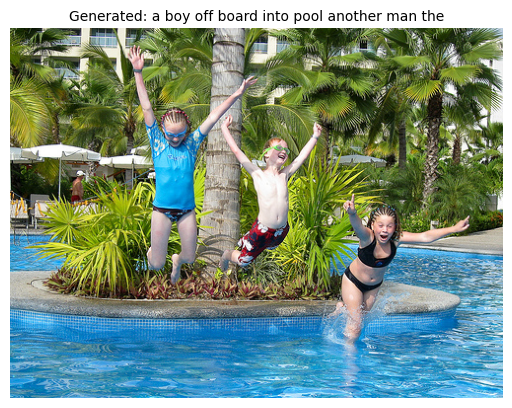

Generated: a boy off board into pool another man the

Real captions:
1. Three children are jumping into the air into a swimming pool at a resort .
2. Three children are jumping into the water under a palm tree .
3. Three children jumping into a pool .
4. Three children jumping into a pool with a palm tree in the middle .
5. Three children jump into a hotel pool from an artificial island .
--------------------------------------------------

Image: 3264464625_c711cc40c6.jpg


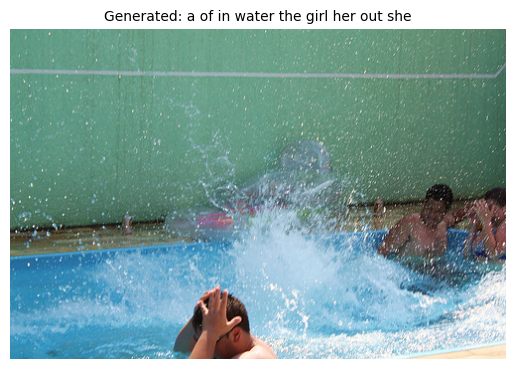

Generated: a of in water the girl her out she

Real captions:
1. "A group of people are in a swimming pool , being splashed ."
2. A large water splash near three swimmers .
3. People are splashed by water coming down a shoot .
4. People in a pool and something just created a large splash .
5. Three people are in a pool dodging a giant splash .
--------------------------------------------------

Image: 3520079657_b828d96d50.jpg


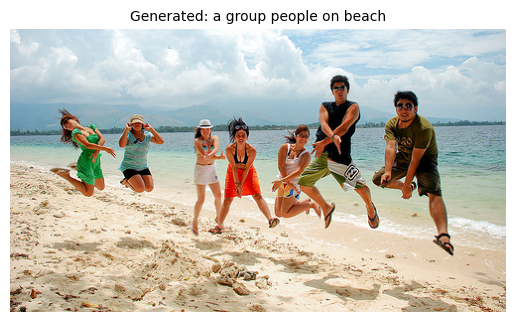

Generated: a group people on beach

Real captions:
1. A group of people jump in the sand at the beach .
2. a group of teenagers are jumping in the air on the beach .
3. A group of young people jump up in the air while on the beach .
4. A group of young people posing in the air on a sandy beach .
5. "Seven people are jumping in the air , along the shore ."
--------------------------------------------------

Image: 2205328215_3ffc094cde.jpg


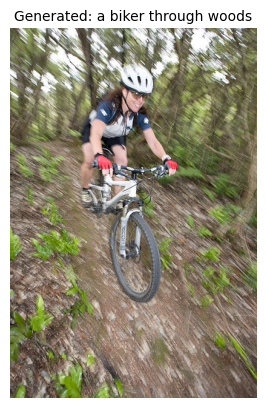

Generated: a biker through woods

Real captions:
1. a long bicyclist wearing a white helmet riding down a mountain path
2. A man riding a bike down a hill .
3. A person on a bike coming down off a wooded hill .
4. A woman is riding a bicycle through a forest .
5. Person riding bicycle down dirt hill in wooded area
--------------------------------------------------


In [89]:
import random

random_images = random.sample([f for f in os.listdir("./flickr8k/Images") if f.endswith(".jpg")], 4)

for img_name in random_images:
    print(f"\nImage: {img_name}")
    test_caption(f"./flickr8k/Images/{img_name}", img_name)
    print("-"*50)

In [92]:
from nltk.translate.bleu_score import corpus_bleu
import nltk
nltk.download('punkt')

references = []
hypotheses = []

test_images = random.sample([f for f in os.listdir("./flickr8k/Images") if f.endswith(".jpg")], 200)

for img_name in test_images:
    image = Image.open(f"./flickr8k/Images/{img_name}").convert("RGB")
    inputs = processor(images=image, return_tensors="pt")
    pixel_values = inputs["pixel_values"].to(device)
    caption = model.beam_search(pixel_values, vocab)
    
    real_caps = [vocab.tokenize(c) for _, c in dataset.data if _ == img_name]
    if real_caps:
        references.append(real_caps)
        hypotheses.append(vocab.tokenize(caption))

bleu1 = corpus_bleu(references, hypotheses, weights=(1,0,0,0))
bleu4 = corpus_bleu(references, hypotheses, weights=(0.25,0.25,0.25,0.25))

print(f"BLEU-1: {bleu1:.4f}")
print(f"BLEU-4: {bleu4:.4f}")

ModuleNotFoundError: No module named 'nltk'